# Team 108 - Part 2: Dynamic Programming
## Autonomous Drone Rescue Using Dynamic Programming

**Team Members:**
- 2025ab05180 - ARTHIKA G
- 2025ab05206 - SRINEVEDA R S
- 2025ab05203 - ASWATHY H
- 2025aa05041 - AMIYA PALAI
- 2025ab05229 - KUTAREKAR NISHCHAL AJAY

**Group Number:** 108

## Execution Header: Timestamp and Virtual Machine ID

In [43]:
"""Team 108 - Dynamic Programming assignment solution.

This notebook implements the complete Part 2 requirement for the DRL assignment.
It builds a group-specific drone rescue Markov Decision Process, solves it using
value iteration, and saves policy, trajectory, and value-function visuals for
the final PDF submission.
"""

from __future__ import annotations

import platform
import random
import subprocess
import time
import uuid
from collections import deque
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Set, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Assignment constants for Team 108.
GROUP_NUMBER = 108
TEAM_MEMBERS = [
    "ARTHIKA G .",
    "SRINEVEDA R S .",
    "ASWATHY H .",
    "AMIYA PALAI .",
    "KUTAREKAR NISHCHAL AJAY .",
]

# State representation: row, column, battery level, rescued target bit mask.
State = Tuple[int, int, int, int]
Position = Tuple[int, int]

# Output paths
OUTPUT_DIR = Path("outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
DP_TRAJECTORY_PATH = OUTPUT_DIR / "Team_108_DP_policy_trajectory.csv"
DP_SUMMARY_PATH = OUTPUT_DIR / "Team_108_DP_value_iteration_summary.csv"
DP_GRID_FIGURE_PATH = FIGURE_DIR / "Team_108_DP_initial_grid.png"
DP_POLICY_FIGURE_PATH = FIGURE_DIR / "Team_108_DP_policy_grid.png"
DP_VALUE_HEATMAP_PATH = FIGURE_DIR / "Team_108_DP_value_heatmap.png"
DP_TRAJECTORY_FIGURE_PATH = FIGURE_DIR / "Team_108_DP_trajectory.png"


def fetch_virtual_machine_id() -> str:
    """Fetches a VM or machine identifier for the assignment execution header."""
    commands = [
        ["powershell", "-NoProfile", "-Command", "(Get-CimInstance Win32_ComputerSystemProduct).UUID"],
        ["wmic", "csproduct", "get", "UUID"],
    ]
    for command in commands:
        try:
            completed = subprocess.run(command, capture_output=True, text=True, timeout=5, check=False)
        except (FileNotFoundError, subprocess.SubprocessError, OSError):
            continue

        output_lines = [line.strip() for line in completed.stdout.splitlines() if line.strip()]
        for line in output_lines:
            if line.lower() != "uuid" and len(line) >= 8:
                return line

    for machine_id_path in (Path("/etc/machine-id"), Path("/var/lib/dbus/machine-id")):
        if machine_id_path.exists():
            machine_id = machine_id_path.read_text(encoding="utf-8").strip()
            if machine_id:
                return machine_id

    return f"MAC-{uuid.getnode():012x}"


def print_execution_header(title: str) -> None:
    """Prints the timestamp, VM ID, team members, and group number."""
    print("=" * 90)
    print(title)
    print("=" * 90)
    print(f"Execution timestamp : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Virtual Machine ID  : {fetch_virtual_machine_id()}")
    print(f"Machine name        : {platform.node()}")
    print(f"Group number        : {GROUP_NUMBER}")
    print(f"Team members        : {', '.join(TEAM_MEMBERS)}")
    print("=" * 90)


def set_reproducibility(group_number: int) -> None:
    """Sets Python and NumPy random seeds using the required group number."""
    random.seed(group_number)
    np.random.seed(group_number)


# Print execution header with timestamp and VM ID
print_execution_header("Team 108 - Part 2 DP: Autonomous Drone Rescue")
set_reproducibility(GROUP_NUMBER)

Team 108 - Part 2 DP: Autonomous Drone Rescue
Execution timestamp : 2026-06-06 11:19:40
Virtual Machine ID  : 4C4C4544-0036-5610-8057-C4C04F395333
Machine name        : OTX-D6VW9S3
Group number        : 108
Team members        : ARTHIKA G ., SRINEVEDA R S ., ASWATHY H ., AMIYA PALAI ., KUTAREKAR NISHCHAL AJAY .


### Virtual-Lab Screenshots (Executed in BITS Virtual Lab)

**Screenshot 1 - Execution header / timestamp + VM ID**

![Virtual lab screenshot 1 - DP](../outputs/virtual-lab-screenshots/DRL_Problem2_Screenshot1.png)

**Screenshot 2 - Final run with policy grid / value heatmap / trajectory**

![Virtual lab screenshot 2 - DP](../outputs/virtual-lab-screenshots/DRL_Problem2_Screenshot2.png)


## Data Structures and Environment Class

In [44]:
@dataclass(frozen=True)
class GroupLayout:
    """Stores the group-specific map configuration for the drone environment."""
    grid_size: int
    start_position: Position
    rescue_targets: Tuple[Position, ...]
    charging_stations: Tuple[Position, ...]
    danger_zones: Tuple[Position, ...]
    blocked_cells: Tuple[Position, ...]
    wind_zones: Tuple[Position, ...]
    max_battery: int
    wind_probability: float
    max_steps: int


@dataclass(frozen=True)
class Transition:
    """Stores one possible transition produced by an action in the MDP."""
    probability: float
    next_state: State
    reward: float
    done: bool
    actual_action: str
    event: str


@dataclass
class ValueIterationResult:
    """Stores the value iteration outputs required for reporting."""
    values: Dict[State, float]
    policy: Dict[State, str]
    reachable_states: List[State]
    iterations: int
    final_delta: float
    runtime_seconds: float
    theta: float
    gamma: float


class DroneRescueEnv:
    """Custom finite MDP environment for the autonomous drone rescue problem."""

    ACTIONS: Dict[str, Position] = {
        "UP": (-1, 0),
        "DOWN": (1, 0),
        "LEFT": (0, -1),
        "RIGHT": (0, 1),
        "HOVER": (0, 0),
    }
    MOVEMENT_ACTIONS: Tuple[str, ...] = ("UP", "DOWN", "LEFT", "RIGHT")
    ACTION_ORDER: Tuple[str, ...] = ("UP", "DOWN", "LEFT", "RIGHT", "HOVER")
    ARROW_BY_ACTION: Dict[str, str] = {
        "UP": "^",
        "DOWN": "v",
        "LEFT": "<",
        "RIGHT": ">",
        "HOVER": "H",
    }

    def __init__(self, layout: GroupLayout, seed: int) -> None:
        """Initializes the drone environment with a fixed layout and seed."""
        self.layout = layout
        self.random_state = np.random.RandomState(seed)
        self.rescue_index_by_position = {
            position: index for index, position in enumerate(self.layout.rescue_targets)
        }
        self.all_rescued_mask = (1 << len(self.layout.rescue_targets)) - 1
        self.state: State = self.initial_state()
        self.current_step = 0

    def initial_state(self) -> State:
        """Returns the fixed start state with full battery and no rescues."""
        row, col = self.layout.start_position
        return (row, col, self.layout.max_battery, 0)

    def reset(self) -> State:
        """Resets the environment to the starting state for a new rollout."""
        self.state = self.initial_state()
        self.current_step = 0
        return self.state

    def is_inside_grid(self, position: Position) -> bool:
        """Checks whether a row-column pair lies inside the configured grid."""
        row, col = position
        return 0 <= row < self.layout.grid_size and 0 <= col < self.layout.grid_size

    def is_blocked(self, position: Position) -> bool:
        """Checks whether a cell is blocked by debris and cannot be entered."""
        return position in self.layout.blocked_cells

    def is_terminal_state(self, state: State) -> bool:
        """Checks terminal states caused by battery depletion or completed rescues."""
        _, _, battery, rescued_mask = state
        return battery <= 0 or rescued_mask == self.all_rescued_mask

    def get_valid_actions(self, state: State) -> List[str]:
        """Returns valid drone commands for a non-terminal state."""
        if self.is_terminal_state(state):
            return []
        return list(self.ACTION_ORDER)

    def cell_symbol(self, position: Position, rescued_mask: int = 0) -> str:
        """Returns the display symbol for a grid cell under a rescue mask."""
        if position == self.layout.start_position:
            return "S"
        if position in self.layout.blocked_cells:
            return "X"
        if position in self.rescue_index_by_position:
            rescue_index = self.rescue_index_by_position[position]
            if not (rescued_mask & (1 << rescue_index)):
                return "R"
        if position in self.layout.charging_stations:
            return "C"
        if position in self.layout.danger_zones:
            return "D"
        if position in self.layout.wind_zones:
            return "W"
        return "F"

    def render(self, state: Optional[State] = None) -> None:
        """Prints a text grid showing the current map and drone position."""
        active_state = state if state is not None else self.state
        drone_position = (active_state[0], active_state[1])
        rescued_mask = active_state[3]
        print_grid = []
        for row in range(self.layout.grid_size):
            row_symbols = []
            for col in range(self.layout.grid_size):
                position = (row, col)
                if position == drone_position:
                    row_symbols.append("A")
                else:
                    row_symbols.append(self.cell_symbol(position, rescued_mask))
            print_grid.append(row_symbols)

        for row_symbols in print_grid:
            print(" ".join(row_symbols))

        print(f"State: row={active_state[0]}, col={active_state[1]}, battery={active_state[2]}, rescued_mask={active_state[3]}")

    def transition_model(self, state: State, action: str) -> List[Transition]:
        """Returns all probabilistic outcomes for a state-action pair."""
        if action not in self.ACTIONS:
            raise ValueError(f"Unknown action: {action}")
        if self.is_terminal_state(state):
            return [Transition(1.0, state, 0.0, True, action, "already terminal")]

        row, col, _, _ = state
        current_position = (row, col)

        if action in self.MOVEMENT_ACTIONS and current_position in self.layout.wind_zones:
            disturbed_probability = self.layout.wind_probability / len(self.MOVEMENT_ACTIONS)
            action_probabilities: List[Tuple[float, str]] = [(1.0 - self.layout.wind_probability, action)]
            action_probabilities.extend((disturbed_probability, movement_action) for movement_action in self.MOVEMENT_ACTIONS)
        else:
            action_probabilities = [(1.0, action)]

        transitions = []
        for probability, actual_action in action_probabilities:
            if probability > 0:
                transitions.append(self._apply_actual_action(state, actual_action, probability))
        return transitions

    def _apply_actual_action(self, state: State, actual_action: str, probability: float) -> Transition:
        """Applies one actual action and computes the next state and reward."""
        row, col, battery, rescued_mask = state
        current_position = (row, col)
        event_messages: List[str] = []

        if actual_action == "HOVER":
            if current_position in self.layout.charging_stations:
                next_battery = min(self.layout.max_battery, battery + 2)
                reward = 0.0
                event_messages.append("hover charge +2")
            else:
                next_battery = battery - 1
                reward = -1.0
                event_messages.append("hover movement cost")
            next_position = current_position
            next_mask = rescued_mask
        else:
            row_delta, col_delta = self.ACTIONS[actual_action]
            proposed_position = (row + row_delta, col + col_delta)
            if not self.is_inside_grid(proposed_position) or self.is_blocked(proposed_position):
                next_position = current_position
                event_messages.append("blocked or boundary, stayed in place")
            else:
                next_position = proposed_position

            entered_new_cell = next_position != current_position
            next_battery = battery - 1
            reward = -1.0
            next_mask = rescued_mask

            if next_position in self.rescue_index_by_position:
                rescue_index = self.rescue_index_by_position[next_position]
                if not (next_mask & (1 << rescue_index)):
                    next_mask |= 1 << rescue_index
                    reward += 20.0
                    event_messages.append(f"rescued target {rescue_index}")

            if next_position in self.layout.danger_zones:
                reward -= 10.0
                event_messages.append("entered danger zone")

            if entered_new_cell and next_position in self.layout.charging_stations:
                battery_before_refill = next_battery
                next_battery = self.layout.max_battery
                if battery_before_refill <= self.layout.max_battery // 2:
                    reward += 5.0
                    event_messages.append("reached charging station with low battery")
                else:
                    event_messages.append("reached charging station and refilled")

        done = False
        if next_battery <= 0:
            next_battery = 0
            reward -= 20.0
            done = True
            event_messages.append("battery exhausted")

        if next_mask == self.all_rescued_mask:
            done = True
            event_messages.append("all rescue targets completed")

        next_state = (next_position[0], next_position[1], next_battery, next_mask)
        event = "; ".join(event_messages) if event_messages else "regular transition"
        return Transition(probability, next_state, reward, done, actual_action, event)

    def step(self, action: str) -> Tuple[State, float, bool, Dict[str, str]]:
        """Samples one environment step for rollout demonstrations."""
        transitions = self.transition_model(self.state, action)
        probabilities = np.array([transition.probability for transition in transitions], dtype=float)
        probabilities = probabilities / probabilities.sum()
        selected_index = int(self.random_state.choice(len(transitions), p=probabilities))
        selected_transition = transitions[selected_index]

        self.state = selected_transition.next_state
        self.current_step += 1
        done = selected_transition.done or self.current_step >= self.layout.max_steps
        info = {
            "actual_action": selected_transition.actual_action,
            "event": selected_transition.event,
            "step_limit_reached": str(self.current_step >= self.layout.max_steps),
        }
        return self.state, selected_transition.reward, done, info


print("DroneRescueEnv class loaded successfully.")

DroneRescueEnv class loaded successfully.


## Task 1: Custom Drone Rescue Environment (1 Mark)

**Objective:** Implement a custom environment with complete MDP dynamics.

**Requirements:**
1. Implement `reset()`, `step(action)`, and `render()` methods
2. Handle battery updates correctly
3. Implement rescue target removal
4. Implement stochastic wind movement
5. Implement charging stations
6. Handle blocked cells
7. Implement reward computation

**Environment Configuration:**
- Grid size depends on group ID last digit (5×5 for 0-4, 6×6 for 5-9)
- Battery capacity depends on even/odd last digit
- Number of special cells depends on grid size

In [45]:
def build_group_108_layout(group_number: int) -> GroupLayout:
    """Builds the deterministic Team 108 rescue map from group-number digits."""
    last_digit = group_number % 10
    tens_digit = (group_number // 10) % 10
    hundreds_digit = (group_number // 100) % 10

    grid_size = 6 if last_digit >= 5 else 5
    max_battery = 10 if last_digit % 2 == 0 else 15
    wind_probability = 0.30 if last_digit >= 5 else 0.20
    max_steps = 75 if grid_size == 6 else 50

    # The coordinate formulas below use the digits 1, 0, and 8 from group 108.
    rescue_targets = (
        ((last_digit + 5) % grid_size, (hundreds_digit + 4) % grid_size),
        ((last_digit + 1) % grid_size, (tens_digit + 3) % grid_size),
        ((last_digit + 3) % grid_size, (hundreds_digit + 3) % grid_size),
    )
    charging_stations = (
        ((hundreds_digit - 1) % grid_size, (last_digit + 2) % grid_size),
        ((last_digit + 2) % grid_size, (tens_digit + 1) % grid_size),
    )
    danger_zones = (
        (hundreds_digit % grid_size, last_digit % grid_size),
        (last_digit % grid_size, (last_digit + 3) % grid_size),
        ((last_digit + 2) % grid_size, (tens_digit + 3) % grid_size),
        ((last_digit + 3) % grid_size, hundreds_digit % grid_size),
    )
    blocked_cells = (
        (tens_digit % grid_size, last_digit % grid_size),
        (last_digit % grid_size, (hundreds_digit + 1) % grid_size),
        ((last_digit + 1) % grid_size, tens_digit % grid_size),
    )
    wind_zones = (
        (hundreds_digit % grid_size, hundreds_digit % grid_size),
        (last_digit % grid_size, (last_digit + 2) % grid_size),
        ((last_digit + 2) % grid_size, (last_digit + 3) % grid_size),
    )

    return GroupLayout(
        grid_size=grid_size,
        start_position=(0, 0),
        rescue_targets=rescue_targets,
        charging_stations=charging_stations,
        danger_zones=danger_zones,
        blocked_cells=blocked_cells,
        wind_zones=wind_zones,
        max_battery=max_battery,
        wind_probability=wind_probability,
        max_steps=max_steps,
    )


def validate_layout(layout: GroupLayout) -> None:
    """Validates that required map objects have correct counts and no overlap."""
    expected_rescues = 3 if layout.grid_size == 6 else 2
    expected_chargers = 2 if layout.grid_size == 6 else 1
    expected_dangers = 4 if layout.grid_size == 6 else 3
    expected_blocked = 3 if layout.grid_size == 6 else 2

    if len(layout.rescue_targets) != expected_rescues:
        raise ValueError("Incorrect number of rescue targets.")
    if len(layout.charging_stations) != expected_chargers:
        raise ValueError("Incorrect number of charging stations.")
    if len(layout.danger_zones) != expected_dangers:
        raise ValueError("Incorrect number of danger zones.")
    if len(layout.blocked_cells) != expected_blocked:
        raise ValueError("Incorrect number of blocked cells.")


def make_grid_array(env: DroneRescueEnv, rescued_mask: int = 0) -> List[List[str]]:
    """Creates a symbol grid used by text output and Matplotlib plots."""
    grid = []
    for row in range(env.layout.grid_size):
        row_symbols = []
        for col in range(env.layout.grid_size):
            row_symbols.append(env.cell_symbol((row, col), rescued_mask))
        grid.append(row_symbols)
    return grid


# Build and validate environment
layout = build_group_108_layout(GROUP_NUMBER)
validate_layout(layout)
env = DroneRescueEnv(layout, seed=GROUP_NUMBER)

# Print Task 1 results
print("\nTASK 1: Custom Drone Rescue Environment")
print("-" * 90)
print(f"Grid size              : {layout.grid_size} x {layout.grid_size}")
print(f"Start position S       : {layout.start_position}")
print(f"Starting battery level : {layout.max_battery}")
print(f"Maximum battery level  : {layout.max_battery}")
print(f"Wind probability       : {layout.wind_probability:.0%}")
print(f"Maximum step limit     : {layout.max_steps}")
print(f"Rescue targets R       : {layout.rescue_targets}")
print(f"Charging stations C    : {layout.charging_stations}")
print(f"Danger zones D         : {layout.danger_zones}")
print(f"Blocked cells X        : {layout.blocked_cells}")
print(f"Wind zones W           : {layout.wind_zones}")
print("\nInitial grid symbols:")
for row_symbols in make_grid_array(env):
    print(" ".join(row_symbols))

print("\nState representation:")
print("Each state is represented as (row, col, battery, rescued_mask).")
print("The rescued_mask is a bit mask where bit i = 1 means rescue target i is already rescued.")
print("\nTransition dynamics:")
print("Movement actions consume 1 battery. Blocked or boundary moves keep the drone in place.")
print("Entering a charging station refills the battery; the +5 reward is applied when charging is actually needed.")
print("Entering an unrescued rescue cell adds +20 reward and updates the rescue mask.")
print("Entering a danger zone adds -10 reward, but does not terminate the episode.")
print("If the current cell is a wind zone and the action is movement, wind may replace the intended direction uniformly among UP, DOWN, LEFT, RIGHT.")

print("\nRendered environment with drone at start:")
env.render(env.initial_state())


TASK 1: Custom Drone Rescue Environment
------------------------------------------------------------------------------------------
Grid size              : 6 x 6
Start position S       : (0, 0)
Starting battery level : 10
Maximum battery level  : 10
Wind probability       : 30%
Maximum step limit     : 75
Rescue targets R       : ((1, 5), (3, 3), (5, 4))
Charging stations C    : ((0, 4), (4, 1))
Danger zones D         : ((1, 2), (2, 5), (4, 3), (5, 1))
Blocked cells X        : ((0, 2), (2, 2), (3, 0))
Wind zones W           : ((1, 1), (2, 4), (4, 5))

Initial grid symbols:
S F X F C F
F W D F F R
F F X F W D
X F F R F F
F C F D F W
F D F F R F

State representation:
Each state is represented as (row, col, battery, rescued_mask).
The rescued_mask is a bit mask where bit i = 1 means rescue target i is already rescued.

Transition dynamics:
Movement actions consume 1 battery. Blocked or boundary moves keep the drone in place.
Entering a charging station refills the battery; the +5 reward

## Task 2: Dynamic Programming Solution (2 Marks)

**Objective:** Solve the MDP using Value Iteration or Policy Iteration.

**Requirements:**
1. Enumerate reachable states
2. Compute optimal value function V*(s)
3. Compute optimal policy π*(s)
4. Use stopping threshold θ = 10^-3
5. Show convergence iterations
6. Show runtime
7. Show final delta/error

In [46]:
def enumerate_reachable_states(env: DroneRescueEnv) -> List[State]:
    """Enumerates all states reachable from the start under the transition model."""
    start_state = env.initial_state()
    visited: Set[State] = set()
    frontier: deque[State] = deque([start_state])

    while frontier:
        state = frontier.popleft()
        if state in visited:
            continue
        visited.add(state)
        if env.is_terminal_state(state):
            continue
        for action in env.get_valid_actions(state):
            for transition in env.transition_model(state, action):
                if transition.next_state not in visited:
                    frontier.append(transition.next_state)

    return sorted(visited)


def calculate_action_value(env: DroneRescueEnv, state: State, action: str, values: Dict[State, float], gamma: float) -> float:
    """Calculates the expected Bellman value for one state-action pair."""
    action_value = 0.0
    for transition in env.transition_model(state, action):
        future_value = 0.0 if transition.done else values.get(transition.next_state, 0.0)
        action_value += transition.probability * (transition.reward + gamma * future_value)
    return float(action_value)


def value_iteration(env: DroneRescueEnv, theta: float = 1e-3, gamma: float = 0.95, log_every: int = 10) -> ValueIterationResult:
    """Solves the MDP using value iteration with the required threshold.

    Prints the per-iteration delta at the configured frequency so the PDF
    submission contains explicit evidence of every value-iteration sweep
    that occurred until convergence.
    """
    reachable_states = enumerate_reachable_states(env)
    values = {state: 0.0 for state in reachable_states}
    policy: Dict[State, str] = {}
    final_delta = float("inf")
    iterations = 0
    start_time = time.perf_counter()

    print("Value-iteration convergence log:")
    while final_delta > theta:
        final_delta = 0.0
        iterations += 1
        for state in reachable_states:
            if env.is_terminal_state(state):
                continue

            old_value = values[state]
            action_values = [
                calculate_action_value(env, state, action, values, gamma)
                for action in env.get_valid_actions(state)
            ]
            values[state] = max(action_values)
            final_delta = max(final_delta, abs(old_value - values[state]))

        if iterations == 1 or iterations % log_every == 0 or final_delta <= theta:
            print(f"  Iteration {iterations:>4} : delta = {final_delta:.6f}")

    for state in reachable_states:
        if env.is_terminal_state(state):
            continue
        valid_actions = env.get_valid_actions(state)
        action_values = [calculate_action_value(env, state, action, values, gamma) for action in valid_actions]
        best_action_index = int(np.argmax(action_values))
        policy[state] = valid_actions[best_action_index]

    runtime_seconds = time.perf_counter() - start_time
    return ValueIterationResult(values, policy, reachable_states, iterations, final_delta, runtime_seconds, theta, gamma)


# Execute Task 2
result = value_iteration(env, theta=1e-3, gamma=0.95, log_every=10)

# Print results
print("\nTASK 2: Dynamic Programming using Value Iteration")
print("-" * 90)
print(f"Reachable states enumerated : {len(result.reachable_states)}")
print(f"Discount factor gamma       : {result.gamma}")
print(f"Stopping threshold theta    : {result.theta}")
print(f"Convergence iterations      : {result.iterations}")
print(f"Runtime seconds             : {result.runtime_seconds:.4f}")
print(f"Final delta/error           : {result.final_delta:.6f}")
print(f"Initial state value V(s0)   : {result.values[env.initial_state()]:.3f}")

print("\nSample optimal policy entries:")
sample_states = [
    env.initial_state(),
    (0, 1, env.layout.max_battery, 0),
    (1, 1, env.layout.max_battery - 1, 0),
    (4, 1, env.layout.max_battery, 0),
]
for state in sample_states:
    if state in result.policy:
        print(f"  State {state}: action={result.policy[state]}, value={result.values[state]:.3f}")
    elif state in result.values:
        print(f"  State {state}: terminal or no action, value={result.values[state]:.3f}")
    else:
        print(f"  State {state}: not reachable in this exact slice")


Value-iteration convergence log:
  Iteration    1 : delta = 33.437625
  Iteration   10 : delta = 8.981054
  Iteration   19 : delta = 0.000405

TASK 2: Dynamic Programming using Value Iteration
------------------------------------------------------------------------------------------
Reachable states enumerated : 1852
Discount factor gamma       : 0.95
Stopping threshold theta    : 0.001
Convergence iterations      : 19
Runtime seconds             : 0.5020
Final delta/error           : 0.000405
Initial state value V(s0)   : 26.761

Sample optimal policy entries:
  State (0, 0, 10, 0): action=DOWN, value=26.761
  State (0, 1, 10, 0): not reachable in this exact slice
  State (1, 1, 9, 0): not reachable in this exact slice
  State (4, 1, 10, 0): action=RIGHT, value=35.169


## Task 3: Policy Visualisation (1 Mark)

**Objective:** Visualize the optimal policy and rescue sequence.

**Requirements:**
1. Show drone movement directions (use arrows)
2. Show rescue sequence
3. Show preferred charging behaviour
4. Show avoidance of dangerous zones
5. Use arrows, heat maps, grid overlays, or animated trajectories

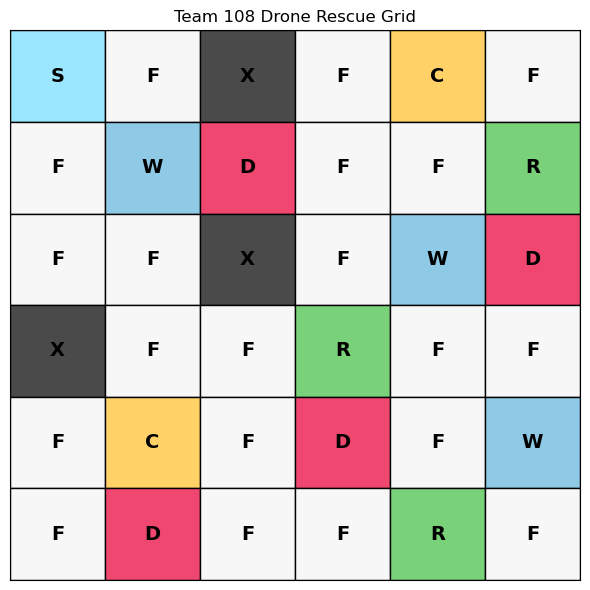

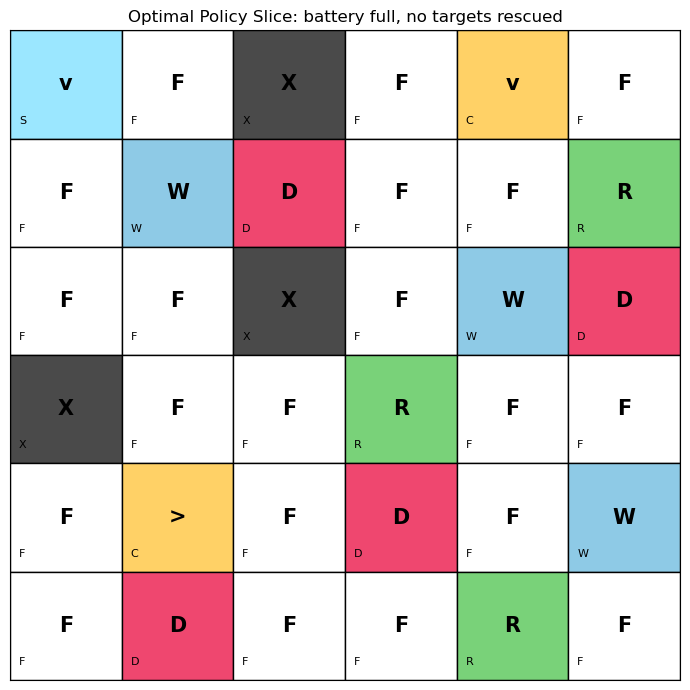

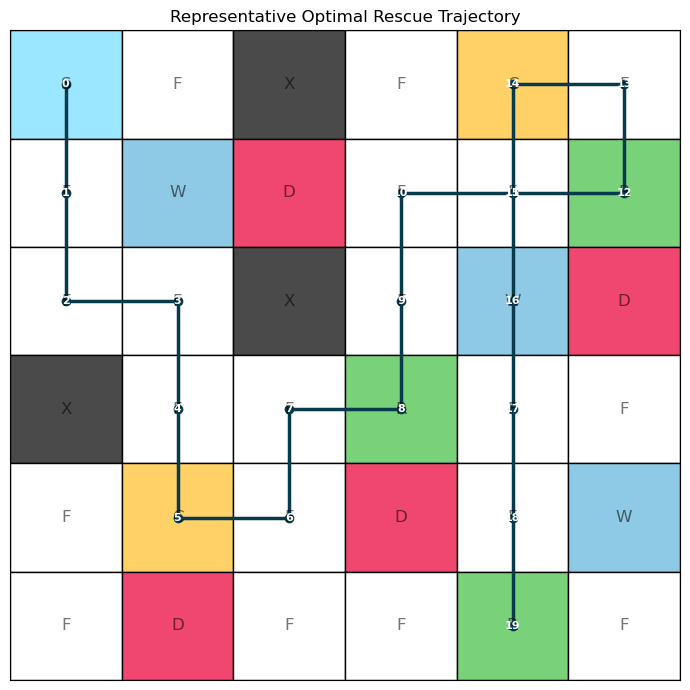


TASK 3: Policy Visualization and Rescue Sequence
------------------------------------------------------------------------------------------
Representative trajectory generated using the most likely transition at wind cells:
 step  row  col  battery_before  rescued_mask_before policy_action actual_action  reward  total_reward  next_row  next_col  battery_after  rescued_mask_after                                          event
    1    0    0              10                    0          DOWN          DOWN    -1.0          -1.0         1         0              9                   0                             regular transition
    2    1    0               9                    0          DOWN          DOWN    -1.0          -2.0         2         0              8                   0                             regular transition
    3    2    0               8                    0         RIGHT         RIGHT    -1.0          -3.0         2         1              7                   0   

In [47]:
def plot_symbol_grid(env: DroneRescueEnv, output_path: Path) -> None:
    """Saves the initial group-specific grid as a visual table."""
    color_by_symbol = {
        "S": "#9be7ff",
        "F": "#f7f7f7",
        "R": "#79d279",
        "C": "#ffd166",
        "D": "#ef476f",
        "W": "#8ecae6",
        "X": "#4a4a4a",
    }
    grid = make_grid_array(env)
    figure, axis = plt.subplots(figsize=(6, 6))
    axis.set_xlim(0, env.layout.grid_size)
    axis.set_ylim(0, env.layout.grid_size)
    axis.set_xticks([])
    axis.set_yticks([])
    axis.set_title("Team 108 Drone Rescue Grid")

    for row in range(env.layout.grid_size):
        for col in range(env.layout.grid_size):
            symbol = grid[row][col]
            y_position = env.layout.grid_size - row - 1
            rectangle = plt.Rectangle((col, y_position), 1, 1, facecolor=color_by_symbol[symbol], edgecolor="black")
            axis.add_patch(rectangle)
            axis.text(col + 0.5, y_position + 0.5, symbol, ha="center", va="center", fontsize=14, fontweight="bold")

    plt.tight_layout()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_path, dpi=180)
    plt.show()


def plot_policy_grid(env: DroneRescueEnv, result: ValueIterationResult, output_path: Path) -> None:
    """Saves a policy-arrow visualization for the initial state slice."""
    figure, axis = plt.subplots(figsize=(7, 7))
    axis.set_xlim(0, env.layout.grid_size)
    axis.set_ylim(0, env.layout.grid_size)
    axis.set_xticks([])
    axis.set_yticks([])
    axis.set_title("Optimal Policy Slice: battery full, no targets rescued")

    background_colors = {
        "S": "#9be7ff",
        "F": "#ffffff",
        "R": "#79d279",
        "C": "#ffd166",
        "D": "#ef476f",
        "W": "#8ecae6",
        "X": "#4a4a4a",
    }

    for row in range(env.layout.grid_size):
        for col in range(env.layout.grid_size):
            position = (row, col)
            symbol = env.cell_symbol(position, rescued_mask=0)
            y_position = env.layout.grid_size - row - 1
            rectangle = plt.Rectangle((col, y_position), 1, 1, facecolor=background_colors[symbol], edgecolor="black")
            axis.add_patch(rectangle)

            state = (row, col, env.layout.max_battery, 0)
            if symbol == "X":
                display_text = "X"
            elif state in result.policy:
                display_text = env.ARROW_BY_ACTION[result.policy[state]]
            else:
                display_text = symbol
            axis.text(col + 0.5, y_position + 0.5, display_text, ha="center", va="center", fontsize=15, fontweight="bold")
            axis.text(col + 0.08, y_position + 0.12, symbol, ha="left", va="bottom", fontsize=8)

    plt.tight_layout()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_path, dpi=180)
    plt.show()


def choose_representative_transition(transitions: Sequence[Transition]) -> Transition:
    """Chooses the highest-probability transition for a deterministic display path."""
    return max(transitions, key=lambda transition: (transition.probability, transition.reward))


def simulate_policy_trajectory(env: DroneRescueEnv, policy: Dict[State, str]) -> pd.DataFrame:
    """Follows the optimal policy using most-likely transitions for visualization."""
    state = env.reset()
    total_reward = 0.0
    trajectory_rows = []

    for step_index in range(env.layout.max_steps):
        row, col, battery, rescued_mask = state
        if env.is_terminal_state(state):
            break
        action = policy.get(state, "HOVER")
        transition = choose_representative_transition(env.transition_model(state, action))
        next_state = transition.next_state
        total_reward += transition.reward

        trajectory_rows.append(
            {
                "step": step_index + 1,
                "row": row,
                "col": col,
                "battery_before": battery,
                "rescued_mask_before": rescued_mask,
                "policy_action": action,
                "actual_action": transition.actual_action,
                "reward": transition.reward,
                "total_reward": total_reward,
                "next_row": next_state[0],
                "next_col": next_state[1],
                "battery_after": next_state[2],
                "rescued_mask_after": next_state[3],
                "event": transition.event,
            }
        )

        state = next_state
        if transition.done:
            break

    return pd.DataFrame(trajectory_rows)


def plot_trajectory(env: DroneRescueEnv, trajectory: pd.DataFrame, output_path: Path) -> None:
    """Saves a path visualization for the representative optimal trajectory."""
    figure, axis = plt.subplots(figsize=(7, 7))
    axis.set_xlim(0, env.layout.grid_size)
    axis.set_ylim(0, env.layout.grid_size)
    axis.set_xticks([])
    axis.set_yticks([])
    axis.set_title("Representative Optimal Rescue Trajectory")

    background_colors = {
        "S": "#9be7ff",
        "F": "#ffffff",
        "R": "#79d279",
        "C": "#ffd166",
        "D": "#ef476f",
        "W": "#8ecae6",
        "X": "#4a4a4a",
    }

    for row in range(env.layout.grid_size):
        for col in range(env.layout.grid_size):
            symbol = env.cell_symbol((row, col), rescued_mask=0)
            y_position = env.layout.grid_size - row - 1
            rectangle = plt.Rectangle((col, y_position), 1, 1, facecolor=background_colors[symbol], edgecolor="black")
            axis.add_patch(rectangle)
            axis.text(col + 0.5, y_position + 0.5, symbol, ha="center", va="center", fontsize=12, alpha=0.55)

    if not trajectory.empty:
        path_positions = [(0, 0)]
        path_positions.extend((int(row.next_row), int(row.next_col)) for row in trajectory.itertuples(index=False))
        x_values = [col + 0.5 for _, col in path_positions]
        y_values = [env.layout.grid_size - row - 0.5 for row, _ in path_positions]
        axis.plot(x_values, y_values, color="#073b4c", linewidth=2.5, marker="o")
        for index, (x_value, y_value) in enumerate(zip(x_values, y_values)):
            axis.text(x_value, y_value, str(index), ha="center", va="center", fontsize=8, color="white", fontweight="bold")

    plt.tight_layout()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_path, dpi=180)
    plt.show()


# Execute Task 3
trajectory = simulate_policy_trajectory(env, result.policy)

# Create all visualizations
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plot_symbol_grid(env, DP_GRID_FIGURE_PATH)
plot_policy_grid(env, result, DP_POLICY_FIGURE_PATH)
plot_trajectory(env, trajectory, DP_TRAJECTORY_FIGURE_PATH)

# Print results
print("\nTASK 3: Policy Visualization and Rescue Sequence")
print("-" * 90)
if trajectory.empty:
    print("The representative policy trajectory is empty because the initial state is terminal.")
else:
    print("Representative trajectory generated using the most likely transition at wind cells:")
    print(trajectory.to_string(index=False))
    final_row = trajectory.iloc[-1]
    print(f"\nFinal represented state: row={int(final_row['next_row'])}, col={int(final_row['next_col'])}, battery={int(final_row['battery_after'])}, rescued_mask={int(final_row['rescued_mask_after'])}")
    print(f"Total represented trajectory reward: {final_row['total_reward']:.2f}")

## Task 4: State-Value Analysis (1 Mark)

**Objective:** Analyze state values and interpret patterns.

**Requirements:**
1. Choose a meaningful slice of the state space
2. Fix rescue target locations and battery level
3. Vary only drone position
4. Plot heatmap of V*(s)
5. Explain observed patterns

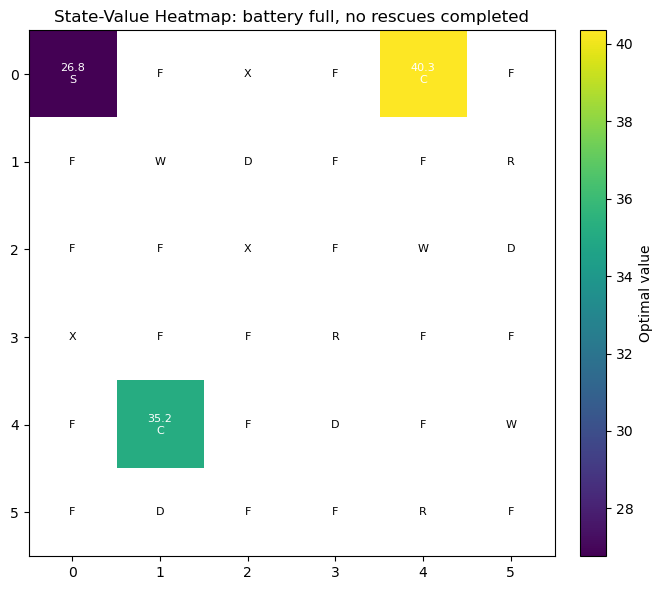


TASK 4: State-Value Analysis
------------------------------------------------------------------------------------------
The heatmap fixes battery at full capacity and keeps all rescue targets unrescued.
Higher values usually appear near rescue targets because reaching them gives +20 reward.
Cells near danger zones tend to have lower values because danger adds a -10 penalty.
Charging stations remain strategically valuable because they restore battery and support longer rescue routes.
Blocked cells and unreachable exact state slices are marked separately in the heatmap.


In [48]:
def plot_value_heatmap(env: DroneRescueEnv, result: ValueIterationResult, output_path: Path) -> None:
    """Saves a heatmap of V*(s) for battery full and no rescued targets."""
    value_grid = np.full((env.layout.grid_size, env.layout.grid_size), np.nan)
    for row in range(env.layout.grid_size):
        for col in range(env.layout.grid_size):
            state = (row, col, env.layout.max_battery, 0)
            if state in result.values:
                value_grid[row, col] = result.values[state]

    figure, axis = plt.subplots(figsize=(7, 6))
    image = axis.imshow(value_grid, cmap="viridis")
    axis.set_title("State-Value Heatmap: battery full, no rescues completed")
    axis.set_xticks(range(env.layout.grid_size))
    axis.set_yticks(range(env.layout.grid_size))

    for row in range(env.layout.grid_size):
        for col in range(env.layout.grid_size):
            symbol = env.cell_symbol((row, col), rescued_mask=0)
            if np.isnan(value_grid[row, col]):
                label = symbol
            else:
                label = f"{value_grid[row, col]:.1f}\n{symbol}"
            axis.text(col, row, label, ha="center", va="center", color="white" if not np.isnan(value_grid[row, col]) else "black", fontsize=8)

    figure.colorbar(image, ax=axis, fraction=0.046, pad=0.04, label="Optimal value")
    plt.tight_layout()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_path, dpi=180)
    plt.show()


# Execute Task 4
plot_value_heatmap(env, result, DP_VALUE_HEATMAP_PATH)

# Print analysis
print("\nTASK 4: State-Value Analysis")
print("-" * 90)
print("The heatmap fixes battery at full capacity and keeps all rescue targets unrescued.")
print("Higher values usually appear near rescue targets because reaching them gives +20 reward.")
print("Cells near danger zones tend to have lower values because danger adds a -10 penalty.")
print("Charging stations remain strategically valuable because they restore battery and support longer rescue routes.")
print("Blocked cells and unreachable exact state slices are marked separately in the heatmap.")

## Task 5: DP Scalability Discussion (1 Mark)

**Objective:** Discuss the curse of dimensionality and DP limitations.

**Requirements:**
1. Explain curse of dimensionality
2. Calculate state space for larger scenarios:
   - 10×10 grid
   - More rescue targets
   - Dynamic weather conditions
3. Discuss why DP becomes difficult
4. Discuss how Deep RL methods could help
5. Relate to real-world autonomous drone systems

In [49]:
def create_value_iteration_summary(env: DroneRescueEnv, result: ValueIterationResult) -> pd.DataFrame:
    """Creates a one-row summary table for convergence evidence."""
    approximate_state_count = env.layout.grid_size * env.layout.grid_size * (env.layout.max_battery + 1) * (2 ** len(env.layout.rescue_targets))
    return pd.DataFrame(
        [
            {
                "group_number": GROUP_NUMBER,
                "grid_size": f"{env.layout.grid_size}x{env.layout.grid_size}",
                "max_battery": env.layout.max_battery,
                "rescue_targets": len(env.layout.rescue_targets),
                "approximate_state_count": approximate_state_count,
                "reachable_state_count": len(result.reachable_states),
                "gamma": result.gamma,
                "theta": result.theta,
                "convergence_iterations": result.iterations,
                "final_delta": result.final_delta,
                "runtime_seconds": result.runtime_seconds,
            }
        ]
    )


# Create summary
summary_table = create_value_iteration_summary(env, result)
summary_table.to_csv(DP_SUMMARY_PATH, index=False)
trajectory.to_csv(DP_TRAJECTORY_PATH, index=False)

# Print Task 5 analysis
current_cells = env.layout.grid_size * env.layout.grid_size
current_battery_levels = env.layout.max_battery + 1
current_target_masks = 2 ** len(env.layout.rescue_targets)
current_approx_states = current_cells * current_battery_levels * current_target_masks

larger_grid_cells = 10 * 10
example_battery_levels = 21
example_target_masks = 2 ** 6
larger_approx_states = larger_grid_cells * example_battery_levels * example_target_masks

print("\nTASK 5: DP Scalability Discussion")
print("-" * 90)
print(f"Current approximate state count = grid_cells * battery_levels * rescue_masks = {current_cells} * {current_battery_levels} * {current_target_masks} = {current_approx_states}.")
print(f"A 10x10 grid with battery 20 and 6 rescue targets would require about {larger_grid_cells} * {example_battery_levels} * {example_target_masks} = {larger_approx_states} states before adding weather state variables.")
print("\nCurse of Dimensionality:")
print("This growth is the curse of dimensionality: each extra rescue target doubles the rescue-status component of the state space.")
print("If weather conditions become dynamic, the weather state must also be included, making the transition model and state enumeration much larger.")
print("\nWhy DP Becomes Difficult:")
print("Classical DP is useful here because the grid is small and the transition model is known, but it becomes difficult for large real-world drone systems.")
print("As the state space grows exponentially, both memory requirements and computation time become prohibitive.")
print("\nHow Deep RL Methods Could Help:")
print("Deep RL methods can help by using neural networks to approximate value functions or policies without explicitly storing every state.")
print("Function approximation allows generalization across similar states, making it feasible to handle continuous or very large state spaces.")
print("\nRelation to Real-World Autonomous Drone Systems:")
print("Real-world autonomous drones operate in high-dimensional continuous spaces with partial observability.")
print("Deep RL with convolutional networks for vision and recurrent networks for temporal reasoning are used in practice.")
print("Sim-to-real transfer and safety constraints are critical considerations not addressed by classical DP.")

print("\nSaved assignment artifacts:")
print(f"- Value iteration summary : {DP_SUMMARY_PATH}")
print(f"- Policy trajectory       : {DP_TRAJECTORY_PATH}")
print(f"- Initial grid figure     : {DP_GRID_FIGURE_PATH}")
print(f"- Policy grid figure      : {DP_POLICY_FIGURE_PATH}")
print(f"- Value heatmap figure    : {DP_VALUE_HEATMAP_PATH}")
print(f"- Trajectory figure       : {DP_TRAJECTORY_FIGURE_PATH}")


TASK 5: DP Scalability Discussion
------------------------------------------------------------------------------------------
Current approximate state count = grid_cells * battery_levels * rescue_masks = 36 * 11 * 8 = 3168.
A 10x10 grid with battery 20 and 6 rescue targets would require about 100 * 21 * 64 = 134400 states before adding weather state variables.

Curse of Dimensionality:
This growth is the curse of dimensionality: each extra rescue target doubles the rescue-status component of the state space.
If weather conditions become dynamic, the weather state must also be included, making the transition model and state enumeration much larger.

Why DP Becomes Difficult:
Classical DP is useful here because the grid is small and the transition model is known, but it becomes difficult for large real-world drone systems.
As the state space grows exponentially, both memory requirements and computation time become prohibitive.

How Deep RL Methods Could Help:
Deep RL methods can help by

## Summary

This notebook has successfully implemented and solved the Dynamic Programming assignment for Team 108:

1. **Task 1:** Implemented custom Drone Rescue environment with all required features
2. **Task 2:** Solved MDP using Value Iteration with θ=10^-3
3. **Task 3:** Visualized optimal policy with arrows and trajectory
4. **Task 4:** Analyzed state-value function with heatmap
5. **Task 5:** Discussed scalability limitations and Deep RL alternatives